# Notebook 1: From Random Walk to Brownian Motion

**Objective:** Visualize how a simple Random Walk, when scaled appropriately, converges to a continuous and erratic process known as Brownian Motion. This will allow us to build a visual intuition as to why we need a new type of calculus to handle these processes.

In [2]:
# Step 1: Simulate a 1D Random Walk 
#
# We create a function to generate a random walk.
# At each step, we move +1 or -1 with equal probability.
# The position at any given time is the cumulative sum of all previous steps.
simular_caminata_1d <- function(n_pasos) {
  # Generate n_pasos randomly as +1 or -1 
  pasos <- sample(c(-1, 1), n_pasos, replace = TRUE)
  # Set seed
  set.seed(1000)
  # Calculate the cumulative position, starting from 0
  posiciones <- cumsum(c(0, pasos))
  
  return(posiciones) # Return the vector of positions 
}

# Simulation parameters
n_pasos <- 1000
caminata <- simular_caminata_1d(n_pasos)

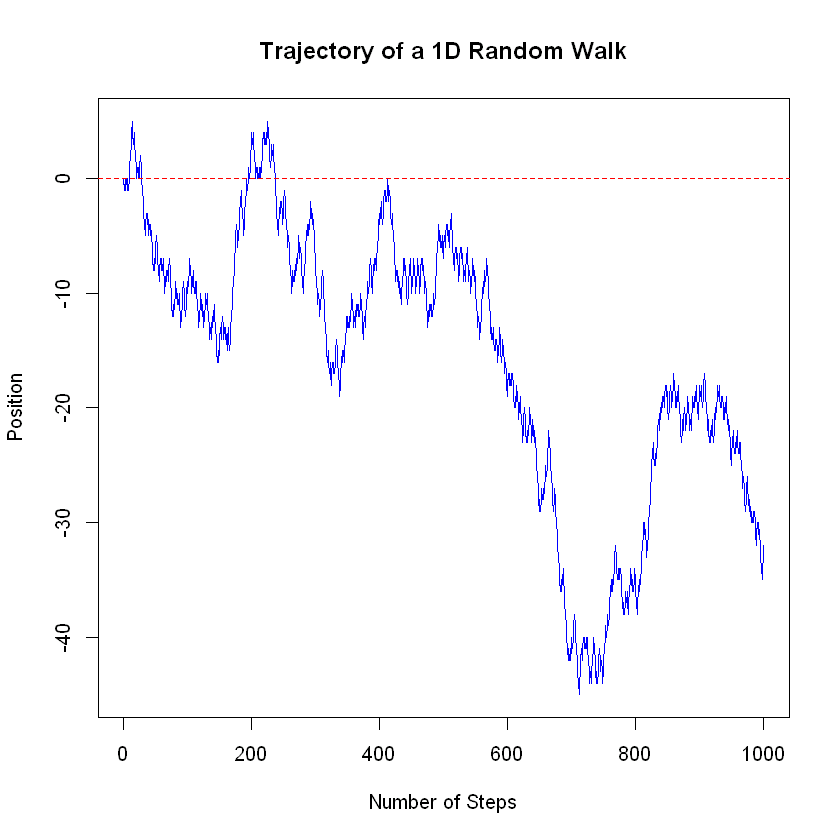

In [3]:
# Step 2: Visualize a trajectory 
#
# We plot the random walk generated in the previous step.
# The X-axis represents the number of steps (time) and the Y-axis represents the position.

plot(0:n_pasos, caminata, type = 'l', col = 'blue',
     main = "Trajectory of a 1D Random Walk",
     xlab = "Number of Steps", ylab = "Position")
abline(h = 0, lty = 2, col = 'red')

### Paso 3: Verify the Final Distribution

Now, we will simulate a large number of random walks to empirically observe which distribution their final positions converge to. This is a practical example of the **Central Limit Theorem**. Theory predicts that the distribution of the final positions should approach a normal distribution.

### Step 4: Donsker's Invariance Principle (Visual)

This principle states that if we appropriately scale the random walk in time and space, it converges to Brownian Motion. The scaling function is:

$\displaystyle W_{n}(t)=\frac{1}{\sqrt{n}}X_{\lfloor nt\rfloor}$ 

As `n` increases, the trajectories become visually "smoother" and more erratic, resembling Brownian Motion.

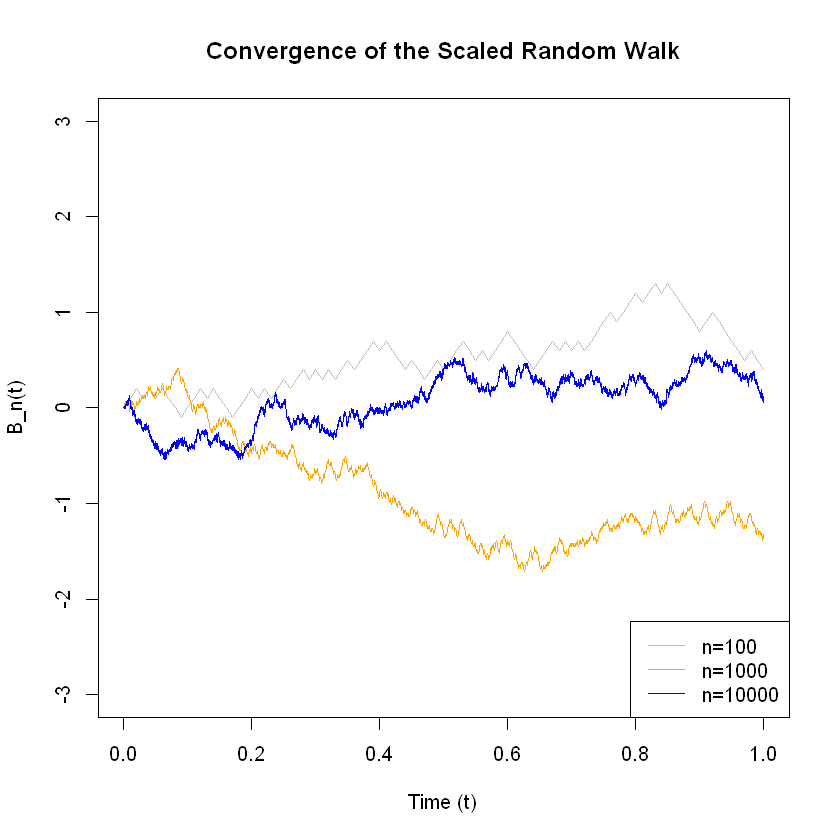

In [5]:
# Step 4: Visualization of Donsker's Invariance Principle

# Function to scale the random walk
escalar_caminata <- function(posiciones) {
  n <- length(posiciones) - 1
  tiempo <- (0:n) / n
  pos_escalada <- posiciones / sqrt(n)
  return(data.frame(tiempo, pos_escalada))
}

# Plot for increasing values of n
plot(NULL, xlim = c(0, 1), ylim = c(-3, 3),
     main = "Convergence of the Scaled Random Walk",
     xlab = "Time (t)", ylab = "B_n(t)")

# n = 100
caminata_100 <- simular_caminata_1d(100)
df_100 <- escalar_caminata(caminata_100)
lines(df_100$tiempo, df_100$pos_escalada, col = 'gray')

# n = 1000
caminata_1000 <- simular_caminata_1d(1000)
df_1000 <- escalar_caminata(caminata_1000)
lines(df_1000$tiempo, df_1000$pos_escalada, col = 'orange')

# n = 10000
caminata_10000 <- simular_caminata_1d(10000)
df_10000 <- escalar_caminata(caminata_10000)
lines(df_10000$tiempo, df_10000$pos_escalada, col = 'blue')

legend("bottomright", legend = c("n=100", "n=1000", "n=10000"),
       col = c("gray", "orange", "blue"), lty = 1)